In [1]:
import netCDF4 as nc
from pathlib import Path
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib as mpl
import matplotlib.path as mpath
import cartopy.feature as cfeature

import seaborn as sns
import matplotlib.colors as cols
from mpl_toolkits.basemap import Basemap

In [2]:
data=nc.Dataset('/home/dell/iHESPdata/B.E.13.BHISTC5.ne120_t12.sehires38.003.sunway.pop.h.nday1.1929-06-01.nc')

lont = data.variables['TLONG'][:600,:]
latt = data.variables['TLAT'][:600,:]
HT = data.variables['HT'][:600,:]/100

In [3]:
WSPno = np.load('/home/dell/iHESPplot/iceplot/smallNo.npy')
WSP = WSPno+250

In [4]:
WSP[:70]

array([250, 251, 255, 256, 259, 260, 290, 291, 292, 293, 294, 295, 296,
       297, 298, 299, 321, 322, 323, 324, 325, 326, 327, 328, 331, 337,
       339, 340, 341, 342, 364, 366, 367, 368, 369, 370, 371, 372, 373,
       413, 415, 416, 417, 418, 419, 420, 421, 422, 423, 424, 425, 426,
       427, 460, 462, 463, 464, 465, 466, 467, 468, 469, 470, 471, 472,
       473, 474, 475, 476, 477])

In [5]:
months = [f"{x:02d}" for x in range(9,10)]
years = [f"{x:04d}" for x in range(298,300)]
i =0
result = np.zeros((2,600,3600))
result2 = np.zeros((2,600,3600))
# /home/hires_pi_ctrl/B.E.13.B1850C5.ne120_t12.sehires38.003.sunway_02/ocn/monthly
for yy in years:
    for mm in months:
        data=nc.Dataset('/media/dell/Elements/new/SDENFsigma1/B.E.13.B1850C5.ne120_t12.sehires38.003.sunway_02.pop.h.'+yy+'-'+mm +'.SDEN_F.nc')
        #data=nc.Dataset('D:\\ihespdata\\B.E.13.BHISTC5.ne120_t12.sehires38.003.sunway.pop.h.'+yy+'-'+mm +'.WMFoffshore.nc')
        plotvar = data.variables['SDEN_F'][0,:600,:]
        plotvar2 = data.variables['sigma1'][0,:600,:]
        plotvar[plotvar == -4.13591295e-01] = np.nan
        plotvar[plotvar >10000] = np.nan
        #plotvar = np.nanmean(plotvar,axis=0)
        result[i,:,:] = plotvar
        result2[i,:,:] = plotvar2
        i = i + 1     
mea = np.nanmean(result, axis=0)
meaddd = np.nanmean(result2, axis=0)

/home/dell/anaconda3/envs/Xiliangdiao/lib/python3.6/site-packages/ipykernel_launcher.py:19: RuntimeWarning: Mean of empty slice


In [6]:
pwd

'/home/dell/iHESPplot/Paper3'

In [7]:
meaddd[meaddd>100] = np.nan
meaddd[meaddd<20] = np.nan

In [8]:
latt = data.variables['TLAT'][:600,:]
lont = data.variables['TLONG'][:600,:]

In [9]:
data.variables['TLAT'][:249,0]

masked_array(data=[ -1.        ,  -1.        ,  -1.        ,  -1.        ,
                    -1.        ,  -1.        ,  -1.        ,  -1.        ,
                    -1.        ,  -1.        ,  -1.        ,  -1.        ,
                    -1.        ,  -1.        ,  -1.        ,  -1.        ,
                    -1.        ,  -1.        ,  -1.        ,  -1.        ,
                    -1.        ,  -1.        ,  -1.        ,  -1.        ,
                    -1.        ,  -1.        ,  -1.        ,  -1.        ,
                    -1.        ,  -1.        ,  -1.        ,  -1.        ,
                    -1.        ,  -1.        ,  -1.        ,  -1.        ,
                    -1.        ,  -1.        ,  -1.        ,  -1.        ,
                    -1.        ,  -1.        ,  -1.        ,  -1.        ,
                    -1.        ,  -1.        ,  -1.        ,  -1.        ,
                    -1.        ,  -1.        ,  -1.        ,  -1.        ,
                    -1.  

In [10]:
lont2 = lont[249,480:1080]
latt2 = latt[249,480:1080]

In [11]:
data.variables['sigma1']

<class 'netCDF4._netCDF4.Variable'>
float64 sigma1(time, nlat, nlon)
    _FillValue: 1e+30
    units: kg/m^3
    long_name: Sigma referenced to z=1000
    coordinates: TLONG TLAT
unlimited dimensions: time
current shape = (1, 2400, 3600)
filling on

In [12]:
#################################################################
nice_cmap=plt.get_cmap('seismic')
#lev_cmap = nice_cmap([250,240,230,220,210,190,180,170,150,130,120,110,100,90,80,70,60,50,40,30,20,10])
lev_cmap = nice_cmap([0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,180,190,200,210,220,230,240,250])
new_cmap = cols.ListedColormap(lev_cmap,"seismic")
nice_levels = [-10,-9,-8,-7,-6,-5,-4,-3,-2,-1,0,1,2,3,4,5,6,7,8,9,10]
#nice_levels = [85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100]
norm = mpl.colors.BoundaryNorm(nice_levels, new_cmap.N)
#################################################################

In [13]:
SDyes = np.load('/home/dell/iHESPplot/iceplot/SDENF/SDENF308310.npy')
Dy = np.load('/home/dell/iHESPplot/iceplot/SDENF/DEN308310.npy')

/home/dell/anaconda3/envs/Xiliangdiao/lib/python3.6/site-packages/ipykernel_launcher.py:29: UserWarning: The following kwargs were not used by contour: 'linewidth'
/home/dell/anaconda3/envs/Xiliangdiao/lib/python3.6/site-packages/ipykernel_launcher.py:60: UserWarning: The following kwargs were not used by contour: 'linewidth'
findfont: Font family ['Cambria'] not found. Falling back to DejaVu Sans.


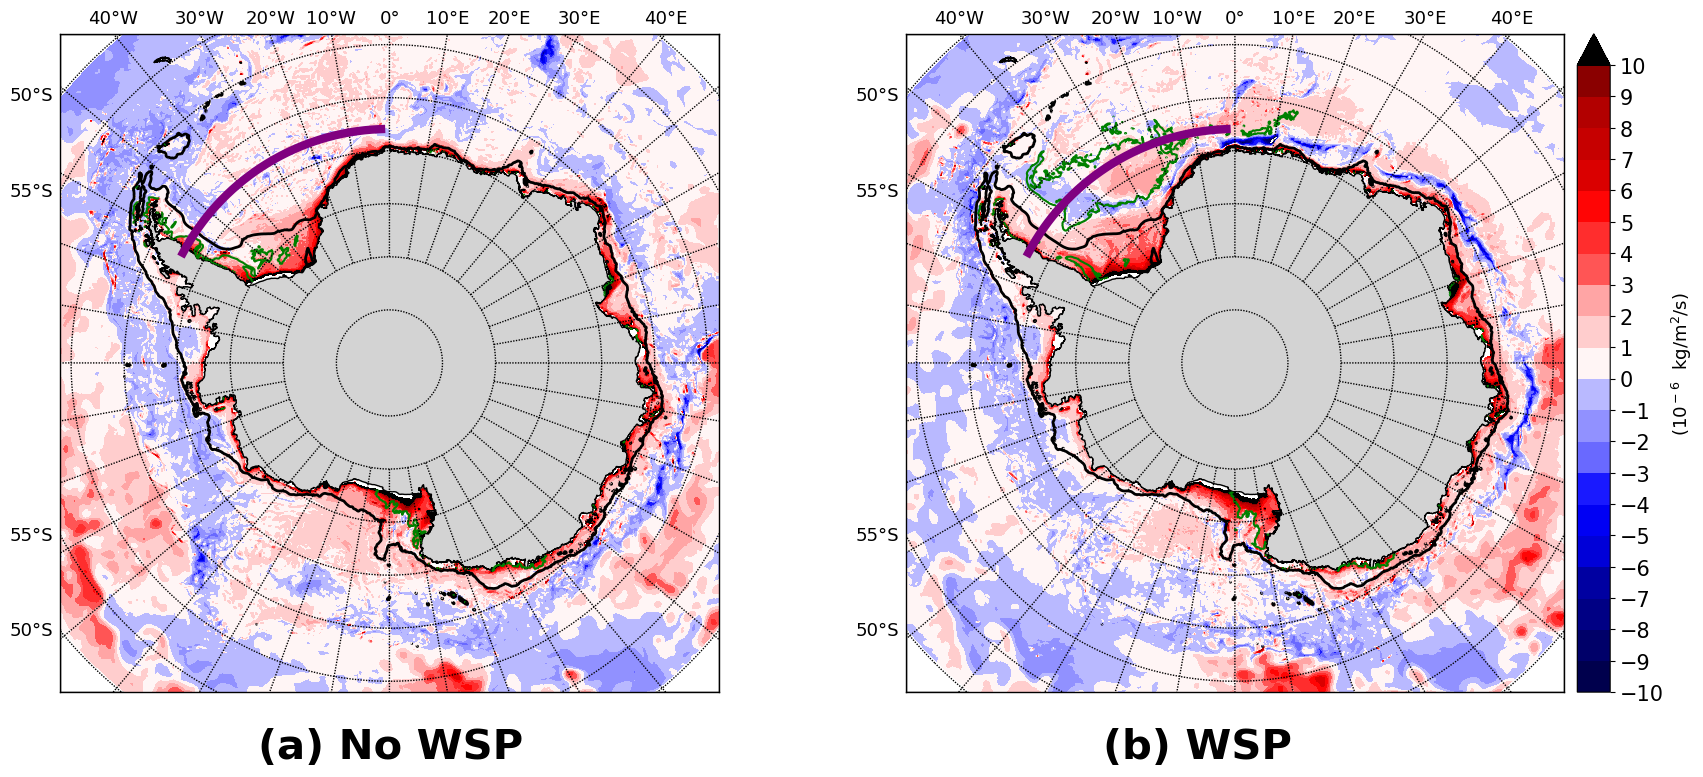

In [14]:
fig = plt.figure(figsize=(20,30), dpi=100)
#ax0 = fig.add_axes([0.1, 0.1, 0.8, 0.36],
                    #xticklabels=[])
ax0 = plt.subplot(1, 2, 1)
my_font = {'fontname':'Cambria', 'size':'13'}
# set the mapping range
map = Basemap(projection='aeqd', lat_0 = -90, lon_0 = 0,area_thresh = 100,\
              #width = 10000000,height = 15000000,resolution ='h')     
              width = 6900000,height = 6900000,resolution ='h') 
map.drawcoastlines()
map.fillcontinents(color = 'lightgrey')
map.drawmapboundary(color='black')
 
map.drawparallels(np.arange(-90,91,5),labels=[1,0,0,0],**my_font)
map.drawmeridians(np.arange(-180,180,10),labels=[0,0,1,0],**my_font)
x,y=map(lont,latt)
CS = map.contour(x[:428,:],y[:428,:],HT[:428,:],[1000],colors= 'black',linestyles = 'solid',linewidths=2)

x,y=map(lont,latt)
CP = map.contourf(x,y,mea[:,:]*1000000,cmap = new_cmap,norm =norm,levels = nice_levels,extend='max')
CP.cmap.set_over('black')
cbar =map.colorbar(CP,ticks = nice_levels)
cbar.ax.tick_params(labelsize=15) 
cbar.set_label('(10$^-$$^6$  kg/m$^2$/s)', **my_font)
cbar.remove()
ax0.text(0.3, -0.1, '(a) No WSP', transform=ax0.transAxes,size=30, weight='bold')
#ax0.text(0.42, 0.48, 'TAUX', transform=ax0.transAxes,size=20, weight='bold')
##############################################################################
ee = map.contour(x,y,meaddd,[32.65], colors='green',linewidth=4)
x2,y2=map(lont2,latt2)
map.plot(x2,y2,'purple',linewidth=6)

#plt.savefig("windnew222.png",bbox_inches='tight')

ax0 = plt.subplot(1, 2, 2)
my_font = {'fontname':'Cambria', 'size':'13'}
# set the mapping range
map = Basemap(projection='aeqd', lat_0 = -90, lon_0 = 0,area_thresh = 100,\
              #width = 10000000,height = 15000000,resolution ='h')     
              width = 6900000,height = 6900000,resolution ='h') 
map.drawcoastlines()
map.fillcontinents(color = 'lightgrey')
map.drawmapboundary(color='black')
 
map.drawparallels(np.arange(-90,91,5),labels=[1,0,0,0],**my_font)
map.drawmeridians(np.arange(-180,180,10),labels=[0,0,1,0],**my_font)

x,y=map(lont,latt)
CS = map.contour(x[:428,:],y[:428,:],HT[:428,:],[1000],colors= 'black',linestyles = 'solid',linewidths=2)
x,y=map(lont,latt)
CP = map.contourf(x,y,SDyes[:,:]*1000000,cmap = new_cmap,norm =norm,levels = nice_levels,extend='max')
CP.cmap.set_over('black')
cbar =map.colorbar(CP,ticks = nice_levels)
cbar.ax.tick_params(labelsize=15) 
cbar.set_label('(10$^-$$^6$  kg/m$^2$/s)', **my_font)
#ax0.text(0.05, 0.05, '(b)', transform=ax0.transAxes,size=30, weight='bold')
ax0.text(0.3, -0.1, '(b) WSP', transform=ax0.transAxes,size=30, weight='bold')
#ax0.text(0.42, 0.48, 'TAUX', transform=ax0.transAxes,size=20, weight='bold')
##############################################################################
ee = map.contour(x,y,Dy,[32.65], colors='green',linewidth=4)
x2,y2=map(lont2,latt2)
map.plot(x2,y2,'purple',linewidth=6)
plt.savefig("FigSSS1.png",bbox_inches='tight')

In [15]:
pwd

'/home/dell/iHESPplot/Paper3'